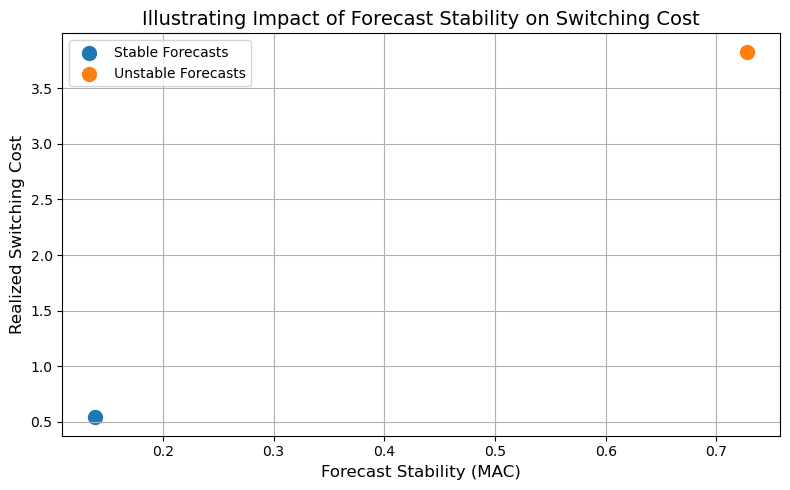

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

T = 20  # Total time steps
v = 4   # Commitment level
n_scenarios = 10  # Number of forecast scenarios

# Generate stable forecast ensemble (low noise, smooth)
stable_forecast = np.cumsum(np.random.normal(0, 0.1, (T, n_scenarios)), axis=0)

# Generate unstable forecast ensemble (higher noise, less smooth)
unstable_forecast = np.cumsum(np.random.normal(0, 0.5, (T, n_scenarios)), axis=0)

# Define a simple policy: mean of the scenario forecasts at each step
def apply_policy(forecast):
    return np.mean(forecast, axis=1)

x_stable = apply_policy(stable_forecast)
x_unstable = apply_policy(unstable_forecast)

# Compute switching costs over commitments of v steps
def switching_cost(x, v):
    return np.sum(np.abs(x[v:] - x[:-v]))

stable_switching_cost = switching_cost(x_stable, v)
unstable_switching_cost = switching_cost(x_unstable, v)

# Compute MAC as a proxy for vertical forecast stability
def compute_mac(forecast, v):
    return np.mean(np.abs(forecast[v:] - forecast[:-v]))

stable_mac = compute_mac(stable_forecast, v)
unstable_mac = compute_mac(unstable_forecast, v)

# Plotting the results
fig, ax = plt.subplots(figsize=(8, 5))

macs = [stable_mac, unstable_mac]
switching_costs = [stable_switching_cost, unstable_switching_cost]
labels = ['Stable Forecasts', 'Unstable Forecasts']

for i in range(2):
    ax.scatter(macs[i], switching_costs[i], label=labels[i], s=100)

ax.set_xlabel("Forecast Stability (MAC)", fontsize=12)
ax.set_ylabel("Realized Switching Cost", fontsize=12)
ax.set_title("Illustrating Impact of Forecast Stability on Switching Cost", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

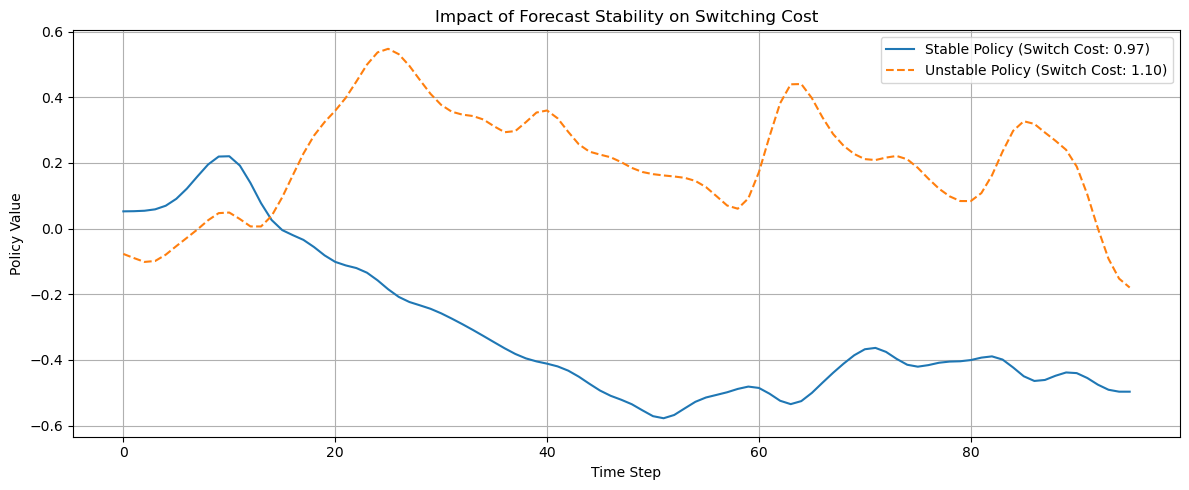

In [2]:
# Set seed for reproducibility
np.random.seed(42)

T = 96  # Time horizon (e.g., 1 day in 15-minute intervals)
v = 12  # Re-optimization interval (every 3 hours)

# Generate stable and unstable forecast trajectories
def generate_forecast_series(stability='stable'):
    if stability == 'stable':
        base = np.cumsum(np.random.normal(0, 0.05, T))
        noise = np.random.normal(0, 0.1, T)
    elif stability == 'unstable':
        base = np.cumsum(np.random.normal(0, 0.05, T))
        noise = np.random.normal(0, 0.3, T)
    forecast = base + noise
    return forecast

# Generate corresponding policy as a smoothed version of the forecast
def generate_policy(forecast):
    from scipy.ndimage import gaussian_filter1d
    return gaussian_filter1d(forecast, sigma=2)

# Compute switching cost
def compute_switching_cost(policy, v):
    updates = range(0, T, v)
    switch_costs = [np.abs(policy[t] - policy[t - v]) for t in updates if t >= v]
    return np.sum(switch_costs)

forecast_stable = generate_forecast_series('stable')
forecast_unstable = generate_forecast_series('unstable')

policy_stable = generate_policy(forecast_stable)
policy_unstable = generate_policy(forecast_unstable)

switch_cost_stable = compute_switching_cost(policy_stable, v)
switch_cost_unstable = compute_switching_cost(policy_unstable, v)

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(policy_stable, label=f'Stable Policy (Switch Cost: {switch_cost_stable:.2f})')
plt.plot(policy_unstable, label=f'Unstable Policy (Switch Cost: {switch_cost_unstable:.2f})', linestyle='--')
plt.xlabel("Time Step")
plt.ylabel("Policy Value")
plt.title("Impact of Forecast Stability on Switching Cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

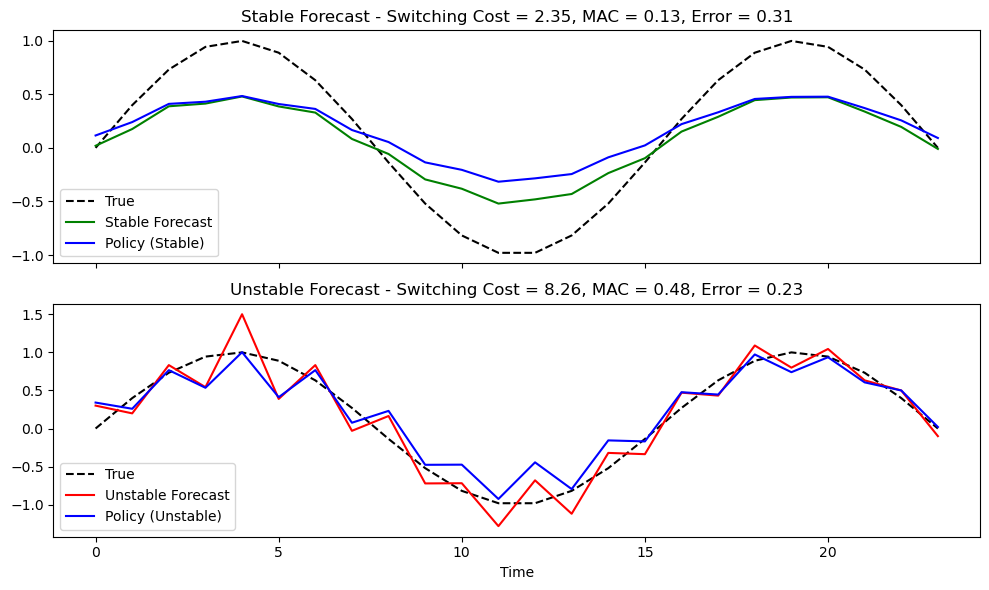

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Time horizon
T = 24

# Ground truth trajectory (e.g., demand or state)
true_trajectory = np.sin(np.linspace(0, 3 * np.pi, T))

# Define forecast error: same for both in magnitude
error = np.array([0.3, -0.2, 0.1, -0.4, 0.5, -0.5, 0.2, -0.3, 0.3, -0.2, 0.1, -0.3,
                  0.3, -0.3, 0.2, -0.2, 0.2, -0.2, 0.2, -0.2, 0.1, -0.1, 0.1, -0.1])

# Stable forecast: error smoothed over time
stable_forecast = true_trajectory + np.convolve(error, np.ones(5)/5, mode='same')

# scale smooth error to match the original error
stable_forecast = stable_forecast * (np.std(error) / np.std(stable_forecast))

# Unstable forecast: use raw error
unstable_forecast = true_trajectory + error

# Policy is a scaled version of forecast (for illustration)
def generate_policy(forecast):
    return np.clip(0.8 * forecast + 0.1, -1, 1)

policy_stable = generate_policy(stable_forecast)
policy_unstable = generate_policy(unstable_forecast)

# Compute switching cost (sum of absolute differences between steps)
def switching_cost(policy):
    return np.sum(np.abs(np.diff(policy)))

# calculate forecast error
forecast_error_stable = np.abs(stable_forecast - true_trajectory)
forecast_error_unstable = np.abs(unstable_forecast - true_trajectory)

# calculate mean absolute change (MAC)
def mean_absolute_change(forecast):
    return np.mean(np.abs(np.diff(forecast)))

mac_stable = mean_absolute_change(stable_forecast)
mac_unstable = mean_absolute_change(unstable_forecast)

cost_stable = switching_cost(policy_stable)
cost_unstable = switching_cost(policy_unstable)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(true_trajectory, 'k--', label='True')
axs[0].plot(stable_forecast, 'g-', label='Stable Forecast')
axs[0].plot(policy_stable, 'b-', label='Policy (Stable)')
axs[0].set_title(f'Stable Forecast - Switching Cost = {cost_stable:.2f}, MAC = {mac_stable:.2f}, Error = {np.mean(forecast_error_stable):.2f}')
axs[0].legend()

axs[1].plot(true_trajectory, 'k--', label='True')
axs[1].plot(unstable_forecast, 'r-', label='Unstable Forecast')
axs[1].plot(policy_unstable, 'b-', label='Policy (Unstable)')
axs[1].set_title(f'Unstable Forecast - Switching Cost = {cost_unstable:.2f}, MAC = {mac_unstable:.2f}, Error = {np.mean(forecast_error_unstable):.2f}')
axs[1].legend()

plt.xlabel('Time')
plt.tight_layout()
plt.show()